In [1]:
import numpy as np
import pandas as pd
from astropy.io import fits
import ipywidgets as widgets
import matplotlib.pyplot as plt
from GCRsim_v02f import CosmicRaySimulation
from ipywidgets import interact, Dropdown, FloatLogSlider, fixed


def group_by_parent_pid(df, sim):
    """Returns dict {parent_pid: sub-DataFrame of all its steps (primary and deltas)}"""
    parent_pid_map = df['PID'].apply(sim.get_parent_pid)
    df['parent_pid'] = parent_pid_map
    grouped = dict(tuple(df.groupby('parent_pid')))
    return grouped

def plot_blob_tracks(df, parent_pid, sim, min_dE=0.0, depth_axis='z'):
    # Filter for this blob
    df_blob = df[df['parent_pid'] == parent_pid]
    if df_blob.empty:
        print("No data for selected blob.")
        return

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # --- Ionization plot (as before) ---
    z_or_x = df_blob['z'].values if depth_axis == 'z' else (df_blob['y'].values if depth_axis == 'y' else df_blob['x'].values)
    target_depth = z_or_x * 1e4 if depth_axis == 'z' else z_or_x * 1e4 # Angstroms, for axis label
    dE = df_blob['dE'].values
    axs[0].scatter(target_depth, dE, color='red', label='dE (Ionization)', s=8)
    # Mark steps where a delta ray is created
    cutoff = min_dE
    mask_delta = df_blob['delta_energy'].abs() > cutoff
    axs[0].scatter(target_depth[mask_delta], dE[mask_delta], facecolors='none', edgecolors='blue', s=40, label='Delta Ray Created')
    axs[0].set_xlabel(f"Target Depth ({'Å' if depth_axis in ['z', 'y', 'x'] else 'μm'})")
    axs[0].set_ylabel("Energy Loss (MeV)")
    axs[0].set_title("Ionization")
    axs[0].legend()

    # --- Middle: Depth vs Y-axis (variable) ---
    if depth_axis == 'z':
        axs[1].scatter(df_blob['z'], df_blob['y'], color='red', s=8)
        axs[1].set_xlabel("Depth z (μm)")
        axs[1].set_ylabel("y (μm)")
        axs[1].set_title("Depth vs. Y-Axis")
    elif depth_axis == 'y':
        axs[1].scatter(df_blob['y'], df_blob['z'], color='red', s=8)
        axs[1].set_xlabel("Depth y (μm)")
        axs[1].set_ylabel("z (μm)")
        axs[1].set_title("Depth y vs. Z")
    else: # depth_axis == 'x'
        axs[1].scatter(df_blob['x'], df_blob['z'], color='red', s=8)
        axs[1].set_xlabel("Depth x (μm)")
        axs[1].set_ylabel("z (μm)")
        axs[1].set_title("Depth x vs. Z")

    # --- Transverse View (always x vs y for now) ---
    axs[2].scatter(df_blob['x'], df_blob['y'], color='red', s=8)
    axs[2].set_xlabel("x (μm)")
    axs[2].set_ylabel("y (μm)")
    axs[2].set_title("Transverse View")

    fig.suptitle(f"Parent {sim.decode_pid(parent_pid)}   (int {parent_pid})", fontsize=18)
    plt.tight_layout()
    plt.show()


def interactive_blob_viewer(csvfile, sim):
    df = pd.read_csv(csvfile)
    df['parent_pid'] = df['PID'].apply(sim.get_parent_pid)
    parent_pids = df['parent_pid'].unique()
    blob_options = [(sim.decode_pid(pid), pid) for pid in parent_pids]
    axis_options = [('Z (depth)', 'z'), ('Y (depth)', 'y'), ('X (depth)', 'x')]
    interact(
        plot_blob_tracks,
        df=fixed(df),
        parent_pid=Dropdown(options=blob_options, description="Parent PID"),
        sim=fixed(sim),
        min_dE=FloatLogSlider(value=0.0, base=10, min=-6, max=0, step=0.1, description="dE cutoff", continuous_update=False),
        depth_axis=Dropdown(options=axis_options, description="Depth Axis")
    )

def plot_blob_tracks_core(df_blob, parent_pid, sim, min_dE=0.0):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Parent {sim.decode_pid(parent_pid)}  (int {parent_pid})', fontsize=18)
    
    df_blob = df_blob.sort_values('step')
    mask_ion = (df_blob['dE'] > min_dE)
    mask_delta = (df_blob['delta_energy'] > 0)
    axs[0].scatter(df_blob.loc[mask_ion, 'z'] * 1e4, df_blob.loc[mask_ion, 'dE'], color='r', s=10, label='dE (Ionization)')
    axs[0].scatter(df_blob.loc[mask_delta, 'z'] * 1e4, df_blob.loc[mask_delta, 'dE'], color='b', edgecolor='k', s=25, marker='o', label='Delta Ray Created')
    axs[0].set_xlabel('Target Depth (Å)')
    axs[0].set_ylabel('Energy Loss (MeV)')
    axs[0].set_title('Ionization')
    axs[0].legend()
    axs[1].scatter(df_blob['z'], df_blob['y'], color='r', s=8)
    axs[1].set_xlabel('Depth z (µm)')
    axs[1].set_ylabel('y (µm)')
    axs[1].set_title('Depth vs. Y-Axis')
    axs[2].scatter(df_blob['x'], df_blob['y'], color='r', s=8)
    axs[2].set_xlabel('x (µm)')
    axs[2].set_ylabel('y (µm)')
    axs[2].set_title('Transverse View')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


In [2]:
sim = CosmicRaySimulation(grid_size=4)
interactive_blob_viewer("Outputs/Sample Outputs/202507241732_energy_loss_3point4secsimNEW.csv", sim)


interactive(children=(Dropdown(description='Parent PID', options=(('H-P0001-D00000', 33570816), ('H-P0003-D000…

In [3]:
def plot_bragg_curve_for_blob(df, parent_pid, bin_width_um=0.05):
    # Filter for the blob/track
    df_blob = df[df['parent_pid'] == parent_pid].copy()
    if df_blob.empty:
        print("No data for this PID.")
        return

    # Sort by z (depth, in um)
    df_blob = df_blob.sort_values('z')
    z_vals = df_blob['z'].values
    dE_vals = df_blob['dE'].values

    # Option 1: Scatter (Bragg curve as step-by-step dE)
    plt.figure(figsize=(7,4))
    plt.scatter(z_vals, dE_vals, c='red', s=8, label='dE per step')
    plt.xlabel("Depth z (μm)")
    plt.ylabel("Energy loss per step (MeV)")
    plt.title(f"Bragg Curve (single blob PID {parent_pid})")
    plt.legend()
    plt.show()

    # Option 2: Bin energy loss by z (for noisy data)
    zmin, zmax = z_vals.min(), z_vals.max()
    bins = np.arange(zmin, zmax + bin_width_um, bin_width_um)
    hist, edges = np.histogram(z_vals, bins=bins, weights=dE_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plt.figure(figsize=(7,4))
    plt.plot(centers, hist, color='blue', label='Total dE per bin')
    plt.xlabel("Depth z (μm)")
    plt.ylabel(f"Energy loss per {bin_width_um:.3f} μm bin (MeV)")
    plt.title(f"Binned Bragg Curve (PID {parent_pid})")
    plt.legend()
    plt.show()

def plot_mean_bragg_curve(df, bin_width_um=0.05):
    # Use all steps in the DataFrame
    z_vals = df['z'].values
    dE_vals = df['dE'].values
    zmin, zmax = z_vals.min(), z_vals.max()
    bins = np.arange(zmin, zmax + bin_width_um, bin_width_um)
    hist, edges = np.histogram(z_vals, bins=bins, weights=dE_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plt.figure(figsize=(7,4))
    plt.plot(centers, hist, color='green', label='Mean dE per bin')
    plt.fill_between(centers, hist, color="green", alpha=0.75)
    plt.xlabel("Depth z (μm)")
    plt.ylabel(f"Mean energy loss per {bin_width_um:.3f} μm bin (MeV)")
    plt.title("Mean Bragg Curve (all tracks)")
    plt.legend()
    plt.show()
    
    # Conversion
    # mean_dE_per_A = mean_dE_per_z * 1e6 / 1e3  # (MeV to eV) divided by (micron to Angstrom for 0.1 um bin)
    # Simplifies to:
    mean_dE_per_A = dE_vals * 1e3
    hist, edges = np.histogram(z_vals, bins=bins, weights=mean_dE_per_A)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Now plot
    plt.figure(figsize=(7,5))
    plt.plot(centers, hist, color='green', label="Mean dE (in eV per Å)")
    plt.fill_between(centers, hist, color="green", alpha=0.75)
    plt.xlabel("Depth z (μm)")
    plt.ylabel("Mean dE per Å (eV/Å)")
    plt.title(f"Mean Bragg Curve")
    plt.legend()
    plt.show()



Found keys: ['gcr_counts', 'gcr_species', 'heatmap', 'streaks']
Data loaded successfully


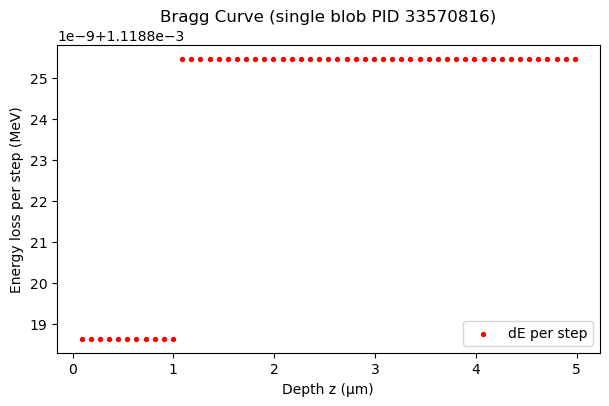

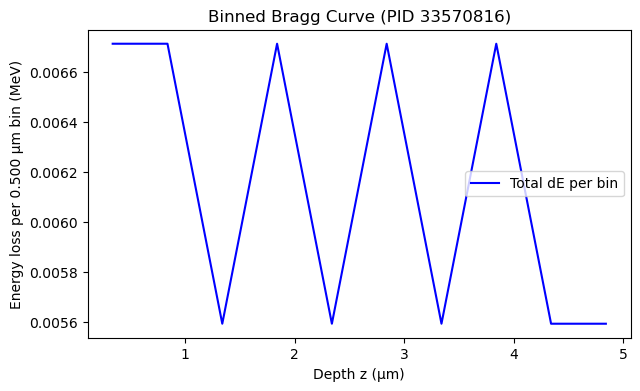

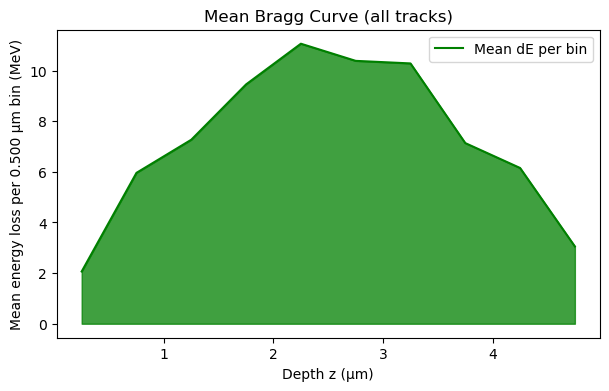

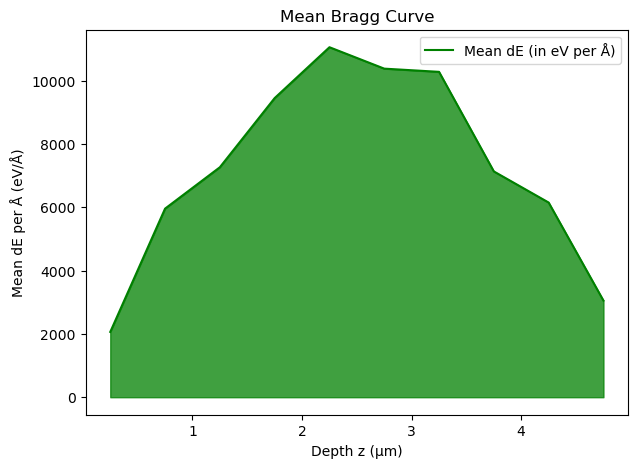

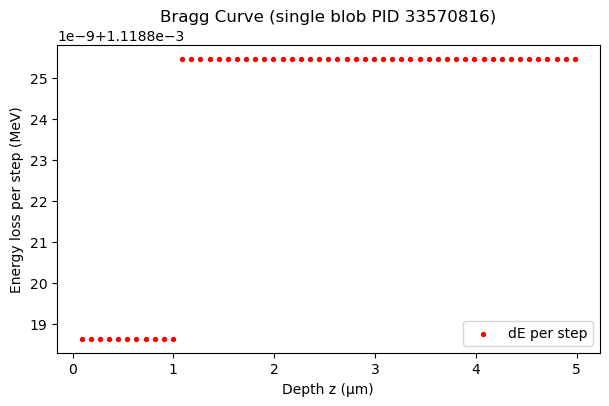

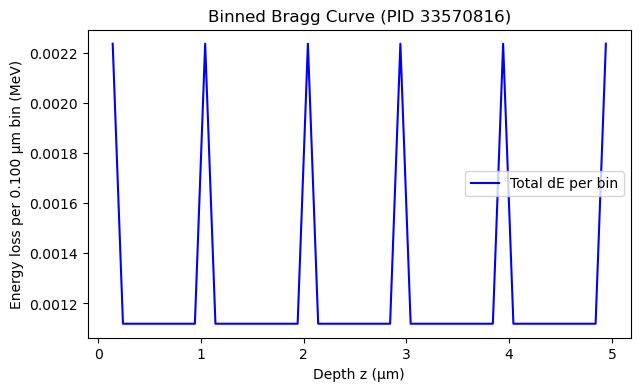

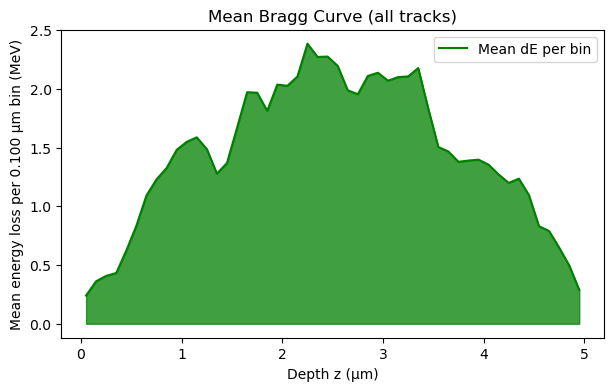

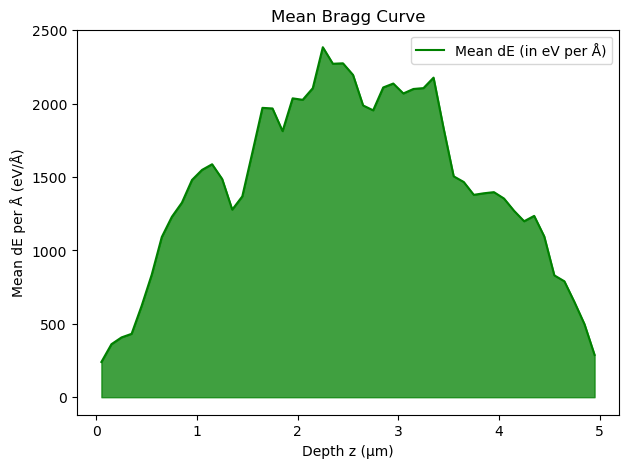

In [4]:
heatmap, streaks_list, gcr_counts = CosmicRaySimulation.load_sim("Outputs/Sample Outputs/3point4sec sim_new_20250724.h5")

# Map parent PID (primary GCR only) to its initial energy (init_en)
parent_initE_dict = {}

for group in streaks_list:
    for sublist in group:
        for streak in sublist:
            pid = streak[1]        # Encoded PID
            is_primary = streak[16]  # True if this is a primary track
            init_en = streak[13]     # Initial energy in MeV (or whatever unit was used)
            if is_primary:
                parent_initE_dict[pid] = init_en


df = pd.read_csv("Outputs/Sample Outputs/202507241732_energy_loss_3point4secsimNEW.csv")

def get_parent_pid(pid):
    return pid & ~((1 << 14) - 1)

# Add parent_pid column if needed
if 'parent_pid' not in df.columns:
    df['parent_pid'] = df['PID'].apply(sim.get_parent_pid)

# Call for a single parent PID (first one, as example)
parent_pid = df['parent_pid'].iloc[0]
plot_bragg_curve_for_blob(df, parent_pid, bin_width_um=0.5)

# Call for the mean over all tracks
plot_mean_bragg_curve(df, bin_width_um=0.5)


df['parent_pid'] = df['PID'].apply(get_parent_pid)
df['primary_init_en'] = df['parent_pid'].map(parent_initE_dict)

plot_bragg_curve_for_blob(df, parent_pid, bin_width_um=0.1)   # finer binning
plot_mean_bragg_curve(df, bin_width_um=0.1)                    # coarser binning


In [5]:
#(df['primary_init_en'].min(), df['primary_init_en'].max())

energy_min = df['primary_init_en'].min()
energy_max = df['primary_init_en'].max()

# To avoid issues, set min > 0, and round a little lower/higher:
energy_bins = np.logspace(np.log10(100), np.log10(50000), num=10)  # 10 bins

df['energy_bin'] = pd.cut(df['primary_init_en'], bins=energy_bins)
print(df[['primary_init_en', 'energy_bin']].drop_duplicates())

       primary_init_en            energy_bin
0           137.639311      (100.0, 199.474]
55          166.171693      (100.0, 199.474]
2597        145.741434      (100.0, 199.474]
2803        200.353925    (199.474, 397.897]
2905        250.508111    (199.474, 397.897]
...                ...                   ...
49107      1639.773256  (1583.223, 3158.114]
50326      1815.706799  (1583.223, 3158.114]
50432      2008.292220  (1583.223, 3158.114]
52319      2043.517627  (1583.223, 3158.114]
52400      2283.210878  (1583.223, 3158.114]

[61 rows x 2 columns]


In [6]:
energy_bin_labels = [str(bin) for bin in df['energy_bin'].cat.categories]
depth_bins = np.linspace(0, 5, 51)  # 0 to 5 um, 0.1 um bins
def plot_bragg_for_bin(bin_label):
    bin_group = df[df['energy_bin'].astype(str) == bin_label]
    mean_dE_per_z = bin_group.groupby(pd.cut(bin_group['z'], bins=depth_bins))['dE'].mean()
    z_centers = (depth_bins[:-1] + depth_bins[1:]) / 2
    plt.figure(figsize=(7,5))
    plt.plot(z_centers, mean_dE_per_z, '-o')
    plt.xlabel("Depth z (μm)")
    plt.ylabel("Mean dE per bin (MeV)")
    plt.title(f"Mean Bragg Curve: Initial E bin {bin_label}")
    plt.show()

interact(plot_bragg_for_bin, bin_label=widgets.Dropdown(options=energy_bin_labels, description="E bin"))


interactive(children=(Dropdown(description='E bin', options=('(100.0, 199.474]', '(199.474, 397.897]', '(397.8…

<function __main__.plot_bragg_for_bin(bin_label)>